# Document Layout Detection: YOLO vs RT-DETR

## Data Preparation

### Validate Data Extraction

In [25]:
# printing length of folder .data/images/train
import os
num_train_images = len(os.listdir(".data/images/train"))
print(f"Number of training images: {num_train_images}")

Number of training images: 5000


Prüfe Bild-ID: 23875
Dokumenten-Kategorie: scientific_articles
-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...
-> 5 Bounding Boxen im JSON für dieses Bild gefunden.


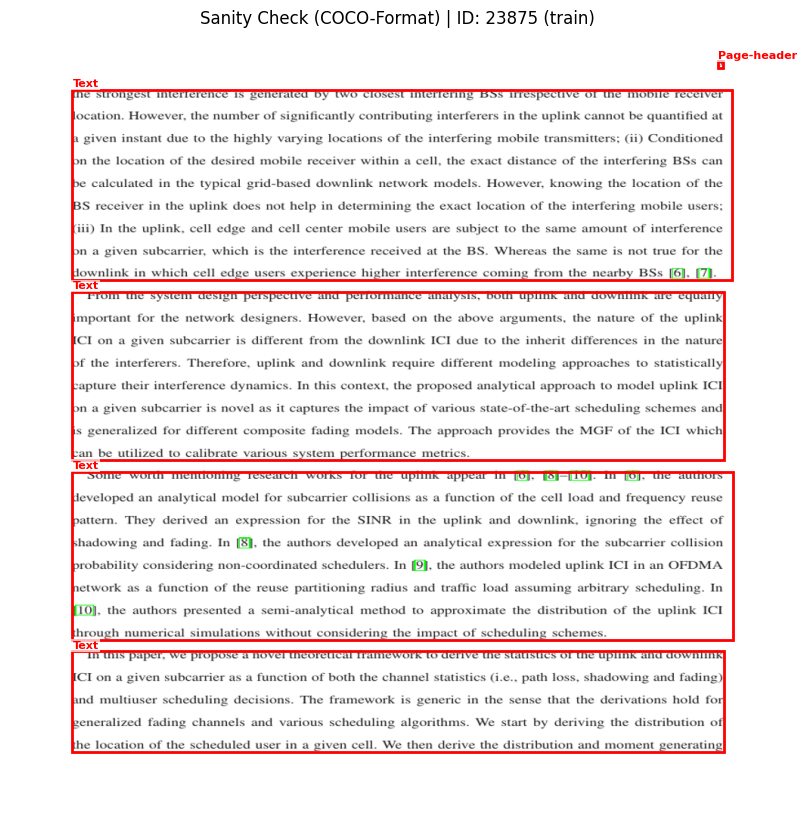

In [28]:
import json
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# PFADE ANPASSEN
SUBSET_DIR = ".data"
SPLIT = "train"  # Welchen Split willst du prüfen? (train, val oder test)

JSON_PATH = f"{SUBSET_DIR}/labels_coco/labels_coco_{SPLIT}.json"
IMAGES_DIR = f"{SUBSET_DIR}/images/{SPLIT}"

# 1. Gekürztes JSON laden
with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

# Mappings für die Visualisierung aufbauen
cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}

# Wir wählen ein zufälliges Bild aus den tatsächlich im JSON registrierten Bildern
random_img_info = random.choice(coco_data['images'])
target_img_id = random_img_info['id']
img_file_name = f"{target_img_id}.png"
img_path = os.path.join(IMAGES_DIR, img_file_name)

print(f"Prüfe Bild-ID: {target_img_id}")
print(f"Dokumenten-Kategorie: {random_img_info.get('doc_category')}")

# 2. Prüfen, ob das Bild auch physisch im Ordner existiert
if not os.path.exists(img_path):
    print(f"FEHLER: Bilddatei {img_file_name} wurde nicht im Ordner {IMAGES_DIR} gefunden!")
    exit()
else:
    print("-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...")

# 3. Alle Annotations filtern, die zu dieser Bild-ID gehören
img_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == target_img_id]
print(f"-> {len(img_annotations)} Bounding Boxen im JSON für dieses Bild gefunden.")

# 4. Visuelle Validierung via Matplotlib
img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)

# Jede Box auf das Bild zeichnen
for ann in img_annotations:
    # COCO Format: [x_min, y_min, width, height] (in absoluten Pixeln)
    x, y, w, h = ann['bbox']
    cat_name = cat_id_to_name[ann['category_id']]
    
    # Rechteck zeichnen (Rand rot, transparent innen)
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Label-Text über die Box setzen
    plt.text(x, y - 4, cat_name, color='red', fontsize=8, weight='bold', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title(f"Sanity Check (COCO-Format) | ID: {target_img_id} ({SPLIT})")
plt.axis('off')

# Anzeige des Plots
plt.show()

### Convert COCO to YOLO Format

In [29]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir=".data/labels_coco/",
    save_dir=".data/converted",
    cls91to80=False,
)

Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_test.json: 100% ━━━━━━━━━━━━ 943/943 3.8Kit/s 0.2s0.1s
Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_train.json: 100% ━━━━━━━━━━━━ 4999/4999 4.0Kit/s 1.2s0.0s
Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_val.json: 100% ━━━━━━━━━━━━ 943/943 4.4Kit/s 0.2s0.0s
COCO data converted successfully.
Results saved to /home/rapha/projects/doclayout-det/.data/converted


In [30]:
import shutil
from pathlib import Path

# Paths
converted_dir = Path(".data/converted/")
dataset_dir = Path(".data")

# Move labels next to images for each split
for split in ["labels_train", "labels_val", "labels_test"]:
    src = converted_dir / "labels" / split
    dst = dataset_dir / "labels" / split
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.glob("*.txt"):
        shutil.move(str(f), str(dst / f.name))

# delete the converted directory after moving the labels
if converted_dir.exists():
    shutil.rmtree(converted_dir)

In [31]:
import json
from pathlib import Path

import yaml

# Read categories from your COCO JSON
with open(".data/labels_coco/labels_coco_train.json") as f:
    coco = json.load(f)

# Build class names matching convert_coco output (category_id - 1)
categories = sorted(coco["categories"], key=lambda x: x["id"])
names = {cat["id"] - 1: cat["name"] for cat in categories}
# NOTE: convert_coco maps class IDs as category_id - 1, so category_id must
# start from 1. If your categories start from 0, add 1 to each ID first.

# Create dataset.yaml
dataset = {
    "path": str(Path(".data").resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names,
}

with open(".data/dataset.yaml", "w") as f:
    yaml.dump(dataset, f, default_flow_style=False)

## Training YOLO

## Training RT-DETR